# Weather Descriptive Analysis -- Tier 1 (Sanity Check)

Notebook version of `09_descriptive_weather.py`'s **Tier 1 / sanity-check**
tier -- same logic, restructured so figures and tables render inline
instead of only saving to disk. Good for a live look/demo; the `.py`
script is still the canonical version for batch runs (e.g. a scheduled
Kodama job) and is where Tier 2 (polished exhibits, still blocked on
having a full multi-decade panel loaded) lives.

**Keep this in sync with `09_descriptive_weather.py` by hand** -- the two
aren't imported from a shared module (the pipeline's numbered scripts,
e.g. `01a_test_prism_extract.py`, aren't import-safe module names anyway,
since Python identifiers can't start with a digit), so a change to one
doesn't propagate to the other automatically.

Run this from `codePYTHON/` (so the relative `dataCSV/` paths below
resolve) with the repo's `.venv` kernel selected.


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Assumes the notebook's working directory is codePYTHON/, same as where
# the .py scripts resolve REPO_ROOT via Path(__file__).resolve().parents[1]
# -- notebooks have no __file__, so this uses cwd instead.
REPO_ROOT = Path.cwd().resolve().parents[0]
print(f"REPO_ROOT resolved to: {REPO_ROOT}")

ID_COLS = ["geoid", "state_fips", "county_fips", "county_name"]
FIGURES_DIR = REPO_ROOT / "figures" / "weather"
TABLES_DIR = REPO_ROOT / "tables" / "weather"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

WINTER_MONTHS = {12, 1, 2}  # Dec, Jan, Feb

# Proof-of-concept state for the per-county spaghetti plot -- Illinois.
# Swap for whichever state is most useful to show Eyal; falls back to
# whatever state actually has data if this one is missing.
PROOF_OF_CONCEPT_STATE_FIPS = "17"


REPO_ROOT resolved to: /tmp/repo_test


## Dataset selection

Pick which dataset the rest of the notebook runs against, then re-run the cells below. Re-run this cell + everything after it to switch from PRISM to ERA5 (or back).

In [2]:
class DatasetConfig:
    """Per-dataset paths, mirroring 06_build_derived_weather_vars.py's
    DatasetConfig pattern so PRISM/ERA5 run through identical logic."""

    def __init__(self, name, monthly_path, derived_path, is_primary=False):
        self.name = name
        self.monthly_path = monthly_path
        self.derived_path = derived_path
        self.is_primary = is_primary  # PRISM = True (main dataset); ERA5 = robustness check


PRISM_CONFIG = DatasetConfig(
    name="PRISM",
    monthly_path=REPO_ROOT / "dataCSV" / "PRISM" / "prism_county_month.csv",
    derived_path=REPO_ROOT / "dataCSV" / "PRISM" / "prism_derived_weather_vars.csv",
    is_primary=True,
)

ERA5_CONFIG = DatasetConfig(
    name="ERA5",
    monthly_path=REPO_ROOT / "dataCSV" / "ERA5" / "era5_county_month.csv",
    derived_path=REPO_ROOT / "dataCSV" / "ERA5" / "era5_derived_weather_vars.csv",
    is_primary=False,
)

# PRISM is the main dataset (ERA5 is a robustness check, not co-equal) --
# start here. Change to ERA5_CONFIG and re-run from this cell down to
# switch datasets.
config = PRISM_CONFIG
print(f"Using dataset: {config.name}")
print(f"  monthly_path: {config.monthly_path}")
print(f"  derived_path: {config.derived_path}")

Using dataset: PRISM
  monthly_path: /tmp/repo_test/dataCSV/PRISM/prism_county_month.csv
  derived_path: /tmp/repo_test/dataCSV/PRISM/prism_derived_weather_vars.csv


## Load + merge the county-year-month panel

Merges 05's raw monthly means with 06's derived vars, on `geoid + year + month`.

In [3]:
def load_weather_panel(config: DatasetConfig) -> pd.DataFrame:
    """Merge 05's raw monthly means with 06's derived vars into one
    county-year-month panel, keyed on geoid + year + month.

    Merging on geoid alone (not the full ID_COLS) is deliberate: geoid
    already uniquely identifies a county, and merging on the free-text
    county_name too risks a silent non-match from a formatting difference
    between the two scripts' outputs. monthly's copies of state_fips/
    county_fips/county_name are kept as canonical; derived's are dropped.
    """
    dtype = {"geoid": str, "state_fips": str, "county_fips": str}

    print(f"Loading {config.name} monthly panel from:\n  {config.monthly_path}")
    monthly = pd.read_csv(config.monthly_path, dtype=dtype)
    print(f"  {len(monthly):,} rows.")

    print(f"Loading {config.name} derived weather vars from:\n  {config.derived_path}")
    derived = pd.read_csv(config.derived_path, dtype=dtype)
    print(f"  {len(derived):,} rows.")

    merge_keys = ["geoid", "year", "month"]
    redundant_id_cols = [c for c in ID_COLS if c != "geoid"]

    # 05 and 06 both independently compute n_days/expected_days/
    # is_incomplete[/dataset_types for PRISM] from the same daily source --
    # check they agree before dropping derived's copies, so a silent
    # divergence between the two scripts doesn't go unnoticed.
    qa_cols = [
        c for c in ("n_days", "expected_days", "is_incomplete", "dataset_types")
        if c in monthly.columns and c in derived.columns
    ]
    if qa_cols:
        check = monthly[merge_keys + qa_cols].merge(
            derived[merge_keys + qa_cols], on=merge_keys, suffixes=("_monthly", "_derived")
        )
        for col in qa_cols:
            mismatched = check[f"{col}_monthly"] != check[f"{col}_derived"]
            if mismatched.any():
                print(
                    f"  Warning: {mismatched.sum():,} row(s) where '{col}' "
                    f"disagrees between the monthly and derived {config.name} "
                    "files -- investigate before trusting either QA column."
                )

    derived_slim = derived.drop(columns=redundant_id_cols + qa_cols)

    merged = monthly.merge(
        derived_slim, on=merge_keys, how="outer", indicator=True, validate="one_to_one"
    )

    unmatched = merged[merged["_merge"] != "both"]
    if not unmatched.empty:
        print(
            f"  Warning: {len(unmatched):,} county-month row(s) present in only "
            f"one of the monthly/derived {config.name} files -- see the "
            "'_merge' column before treating this panel as complete."
        )
    merged = merged.drop(columns="_merge")

    print(
        f"  Merged panel: {len(merged):,} county-month rows, "
        f"{merged['geoid'].nunique():,} counties, "
        f"{merged['year'].nunique()} year(s) "
        f"({merged['year'].min()}-{merged['year'].max()})."
    )
    return merged


df = load_weather_panel(config)
df.head()

Loading PRISM monthly panel from:
  /tmp/repo_test/dataCSV/PRISM/prism_county_month.csv


  74,592 rows.
Loading PRISM derived weather vars from:
  /tmp/repo_test/dataCSV/PRISM/prism_derived_weather_vars.csv


  74,592 rows.
  Merged panel: 74,592 county-month rows, 3,108 counties, 2 year(s) (2020-2021).


,geoid,state_fips,county_fips,county_name,year,month,n_days,ppt_total,tmean_mean,tmin_mean,...,dataset_types,expected_days,is_incomplete,days_below_freezing,freeze_thaw_days,days_precip_gt_10mm,heating_degree_days,cooling_degree_days,mean_temp_c,tmean_variance_c2
0,01001,01,001,Autauga,2020,1,31,197.926575,9.849364,3.767306,...,AN81,31,False,10,10,7,263.627408,0.624353,9.849364,24.826668
1,01001,01,001,Autauga,2020,2,29,262.639709,11.104159,5.226372,...,AN81,29,False,6,6,9,213.331081,3.685032,11.104159,22.267492
2,01001,01,001,Autauga,2020,3,31,161.956354,17.803452,11.932944,...,AN81,31,False,0,0,3,65.613815,49.187483,17.803452,19.946408
3,01001,01,001,Autauga,2020,4,30,183.470696,16.808810,9.777331,...,AN81,30,False,0,0,3,65.160548,19.424855,16.808810,9.671948
4,01001,01,001,Autauga,2020,5,31,91.428339,20.955718,14.400450,...,AN81,31,False,0,0,4,22.231503,103.525438,20.955718,13.358260


## Winter-year construction

December belongs to the *following* winter_year; Jan/Feb belong to their own calendar year's winter_year (e.g. Dec 2020 + Jan 2021 + Feb 2021 -> `winter_year == 2021`).

**TODO:** confirm this matches whatever convention Nicole's population-regression side assumes -- Eyal described this as a shared "handshake" between the weather and wildlife sides.

In [4]:
def add_winter_year(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["winter_year"] = df["year"] + (df["month"] == 12).astype(int)
    return df


def restrict_to_winter(df: pd.DataFrame, complete_only: bool = True) -> pd.DataFrame:
    """Filter to Dec/Jan/Feb rows -- most Phase 4 exhibits are winter-only.

    complete_only=True (default) also drops the boundary winter_year(s)
    that can't have all 3 months present for a given county: the panel's
    very first winter_year has Jan/Feb only (no preceding Dec), and its
    very last has Dec only (no following Jan/Feb). Left in, those show up
    as partial "winters" on a trend/spaghetti plot -- e.g. a single Dec
    reading plotted as if it were a full winter mean, which reads as a
    misleading jump. Mirrors 05/06's convention of flagging incompleteness
    rather than silently averaging over it.
    """
    winter = df[df["month"].isin(WINTER_MONTHS)].copy()
    if not complete_only:
        return winter

    winter["_n_months_in_winter"] = winter.groupby(["geoid", "winter_year"])["month"].transform("nunique")
    incomplete_years = sorted(int(y) for y in winter.loc[winter["_n_months_in_winter"] < 3, "winter_year"].unique())
    if incomplete_years:
        print(
            f"  Note: dropping partial-winter row(s) for winter_year(s) "
            f"{incomplete_years} -- missing Dec and/or Jan/Feb at the panel's "
            "date boundary."
        )
    return winter[winter["_n_months_in_winter"] == 3].drop(columns="_n_months_in_winter")


df = add_winter_year(df)
winter = restrict_to_winter(df)
print(f"Winter-restricted panel: {len(winter):,} rows, winter_year range {winter['winter_year'].min()}-{winter['winter_year'].max()}")

  Note: dropping partial-winter row(s) for winter_year(s) [2020, 2022] -- missing Dec and/or Jan/Feb at the panel's date boundary.
Winter-restricted panel: 9,324 rows, winter_year range 2021-2021


## Summary statistics tables

Matches the task-doc line item: *summary statistics tables for all weather variables, by county, by month, and pooled.*

In [5]:
_NON_WEATHER_COLS = {
    *ID_COLS, "year", "month", "winter_year",
    "n_days", "expected_days", "is_incomplete", "dataset_types",
}


def _weather_variable_columns(df: pd.DataFrame) -> list:
    """Every numeric column that isn't an ID/year/month/QA column."""
    return [
        c for c in df.columns
        if c not in _NON_WEATHER_COLS and pd.api.types.is_numeric_dtype(df[c])
    ]


def summary_stats_table(df: pd.DataFrame, by=None) -> pd.DataFrame:
    """One row per weather variable (by=None, pooled) or one row per
    group x variable (by="county" -> geoid, by="month" -> month):
    mean / sd / min / max / n.
    """
    variables = _weather_variable_columns(df)

    if by is None:
        stats = df[variables].agg(["mean", "std", "min", "max", "count"]).T
        stats.index.name = "variable"
        return stats.reset_index()

    group_col = {"county": "geoid", "month": "month"}.get(by)
    if group_col is None:
        raise ValueError(f"Unsupported `by` value: {by!r} (expected None, 'county', or 'month')")

    grouped = df.groupby(group_col)[variables].agg(["mean", "std", "min", "max", "count"])
    grouped.columns = [f"{var}_{stat}" for var, stat in grouped.columns]
    return grouped.reset_index()

In [6]:
summary_pooled = summary_stats_table(df, by=None)
summary_pooled.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_pooled.csv", index=False)
summary_pooled

,variable,mean,std,min,max,count
0,ppt_total,90.079128,66.631036,0.000000,908.594720,74592.0
1,tmean_mean,13.143236,9.539658,-18.956128,35.753046,74592.0
2,tmin_mean,7.142400,9.411820,-25.040312,28.401070,74592.0
3,tmax_mean,19.137183,9.832924,-13.218669,43.597101,74592.0
4,tdmean_mean,6.913549,9.474914,-21.303370,25.395875,74592.0
5,vpdmin_mean,1.111956,1.317815,0.004785,23.014601,74592.0
6,vpdmax_mean,14.312820,8.534655,0.650497,76.646234,74592.0
7,days_below_freezing,8.234435,10.686603,0.000000,31.000000,74592.0
8,freeze_thaw_days,6.643956,8.445636,0.000000,31.000000,74592.0
9,days_precip_gt_10mm,2.827864,2.323889,0.000000,26.000000,74592.0


In [7]:
summary_by_month = summary_stats_table(df, by="month")
summary_by_month.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_by_month.csv", index=False)
summary_by_month

,month,ppt_total_mean,ppt_total_std,ppt_total_min,ppt_total_max,ppt_total_count,tmean_mean_mean,tmean_mean_std,tmean_mean_min,tmean_mean_max,...,mean_temp_c_mean,mean_temp_c_std,mean_temp_c_min,mean_temp_c_max,mean_temp_c_count,tmean_variance_c2_mean,tmean_variance_c2_std,tmean_variance_c2_min,tmean_variance_c2_max,tmean_variance_c2_count
0,1,77.976092,68.654647,0.129220,908.594720,6216,2.180569,5.945980,-13.392207,21.049087,...,2.180569,5.945980,-13.392207,21.049087,6216,17.416485,9.933429,2.784008,105.137120,6216
1,2,84.422804,76.173124,0.000000,451.071696,6216,0.896207,7.271835,-18.956128,23.387113,...,0.896207,7.271835,-18.956128,23.387113,6216,37.825100,27.334843,0.864703,142.395834,6216
2,3,95.269230,62.413031,0.000000,341.922284,6216,8.834251,5.769116,-5.603900,24.542261,...,8.834251,5.769116,-5.603900,24.542261,6216,18.367520,7.174856,1.585839,67.463409,6216
3,4,84.800131,60.299294,0.000000,388.430725,6216,11.539170,4.773088,-1.069202,26.908080,...,11.539170,4.773088,-1.069202,26.908080,6216,22.662174,10.842306,2.297471,67.921231,6216
4,5,104.383187,63.439906,0.000000,530.670234,6216,16.623988,4.023368,3.727606,27.934110,...,16.623988,4.023368,3.727606,27.934110,6216,20.717006,9.811572,0.975062,53.869482,6216
5,6,107.755184,65.045345,0.000000,489.662634,6216,22.836880,3.232552,8.813421,32.509281,...,22.836880,3.232552,8.813421,32.509281,6216,9.059734,5.815295,0.530286,52.151312,6216
6,7,114.110905,65.328370,0.000000,484.912053,6216,24.634472,2.944243,11.957706,34.733629,...,24.634472,2.944243,11.957706,34.733629,6216,4.040654,2.582961,0.355614,19.785108,6216
7,8,110.583828,76.752142,0.000000,516.960570,6216,24.031720,3.107294,11.054999,35.753046,...,24.031720,3.107294,11.054999,35.753046,6216,5.548901,3.746820,0.227375,29.608031,6216
8,9,85.806760,62.855108,0.000000,483.861466,6216,19.794383,3.636628,7.570785,31.216811,...,19.794383,3.636628,7.570785,31.216811,6216,12.699717,5.532184,0.389506,39.034723,6216
9,10,90.906539,56.875952,0.000000,446.834509,6216,14.055181,5.063831,0.717718,28.031606,...,14.055181,5.063831,0.717718,28.031606,6216,24.004209,15.412014,0.785817,88.898980,6216


In [8]:
summary_by_county = summary_stats_table(df, by="county")
summary_by_county.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_by_county.csv", index=False)
print(f"{len(summary_by_county):,} counties -- showing first 10:")
summary_by_county.head(10)

3,108 counties -- showing first 10:


,geoid,ppt_total_mean,ppt_total_std,ppt_total_min,ppt_total_max,ppt_total_count,tmean_mean_mean,tmean_mean_std,tmean_mean_min,tmean_mean_max,...,mean_temp_c_mean,mean_temp_c_std,mean_temp_c_min,mean_temp_c_max,mean_temp_c_count,tmean_variance_c2_mean,tmean_variance_c2_std,tmean_variance_c2_min,tmean_variance_c2_max,tmean_variance_c2_count
0,01001,139.134512,54.632786,28.659069,262.639709,24,18.300005,6.620591,7.775001,27.493429,...,18.300005,6.620591,7.775001,27.493429,24,13.571431,9.705040,0.777190,38.704053,24
1,01003,157.798046,90.166508,14.680396,347.693958,24,19.974935,5.989629,10.174480,27.668694,...,19.974935,5.989629,10.174480,27.668694,24,12.067598,9.545118,0.994085,36.255425,24
2,01005,138.473435,64.741924,10.107110,322.004638,24,18.921742,6.320099,8.869783,27.511994,...,18.921742,6.320099,8.869783,27.511994,24,13.256666,9.399172,0.734831,31.967673,24
3,01007,148.119168,67.761703,38.413031,341.579837,24,17.992446,6.859028,7.385300,27.553865,...,17.992446,6.859028,7.385300,27.553865,24,14.005531,10.267702,0.826466,44.415860,24
4,01009,161.342300,75.925054,54.758902,338.035547,24,16.359932,7.029626,5.873310,26.528007,...,16.359932,7.029626,5.873310,26.528007,24,14.270984,9.646441,1.132368,40.747841,24
5,01011,142.580681,62.649766,15.504678,276.154007,24,18.588993,6.397217,8.511747,27.553182,...,18.588993,6.397217,8.511747,27.553182,24,13.329498,9.423135,0.671191,33.827316,24
6,01013,135.135745,52.052764,20.763226,207.016529,24,19.148448,6.381838,8.917397,27.992360,...,19.148448,6.381838,8.917397,27.992360,24,13.420347,9.824058,0.590667,36.250259,24
7,01015,142.466845,66.176885,46.546329,282.430047,24,16.681148,6.921510,6.232729,26.637873,...,16.681148,6.921510,6.232729,26.637873,24,13.879121,8.967396,1.008195,32.926016,24
8,01017,146.071119,60.871961,28.095978,292.346586,24,17.261674,6.765148,6.957940,26.880826,...,17.261674,6.765148,6.957940,26.880826,24,13.414696,8.925382,0.795042,32.319240,24
9,01019,140.032463,68.895378,43.512835,304.705762,24,16.384876,7.051721,5.744537,26.640866,...,16.384876,7.051721,5.744537,26.640866,24,13.271657,8.359402,1.299122,31.072343,24


## Trend figures

National + state-level winter trends for mean temperature, days below 32°F (road-conditions covariate), and freeze-thaw days. Unstyled -- this is the sanity-check tier, not the paper-ready version.

In [9]:
def _set_year_axis_limits(ax, year_values):
    """Explicit x-limits with padding -- matplotlib's autoscale on a
    single distinct x-value (as with a short test panel) otherwise
    defaults to a huge, unreadable date-like range.
    """
    year_min, year_max = year_values.min(), year_values.max()
    pad = max(1, round(0.05 * (year_max - year_min)))
    ax.set_xlim(year_min - pad, year_max + pad)


def plot_national_trend(df: pd.DataFrame, variable: str, dataset_name: str, year_col: str = "winter_year"):
    national = df.groupby(year_col)[variable].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(national[year_col], national[variable], marker="o", markersize=4, linewidth=1)
    _set_year_axis_limits(ax, national[year_col])
    ax.set_xlabel(year_col.replace("_", " ").title())
    ax.set_ylabel(variable)
    ax.set_title(f"[{dataset_name}] National mean {variable} by {year_col} -- SANITY CHECK, unstyled")

    out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_national_trend_{variable}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Saved {out_path}")
    # (no plt.close() here -- leaving the figure open lets %matplotlib inline
    # render it below the cell, unlike the .py script's batch version.)


def plot_state_small_multiples(df: pd.DataFrame, variable: str, dataset_name: str, year_col: str = "winter_year"):
    state_year = df.groupby(["state_fips", year_col])[variable].mean().reset_index()
    states = sorted(state_year["state_fips"].unique())
    n_states = len(states)

    n_cols = 6
    n_rows = -(-n_states // n_cols)  # ceil division
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.4 * n_cols, 1.8 * n_rows), sharex=True, sharey=True
    )
    axes = axes.flatten()

    for ax, state in zip(axes, states):
        sub = state_year[state_year["state_fips"] == state]
        ax.plot(sub[year_col], sub[variable], marker="o", markersize=2, linewidth=1)
        ax.set_title(state, fontsize=8)
        ax.tick_params(labelsize=6)

    _set_year_axis_limits(axes[0], state_year[year_col])  # shared axes -- setting one propagates

    for ax in axes[n_states:]:
        ax.axis("off")

    fig.suptitle(f"[{dataset_name}] State-level mean {variable} by {year_col} -- SANITY CHECK, unstyled")
    fig.tight_layout()

    out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_state_small_multiples_{variable}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Saved {out_path}")


def plot_county_spaghetti(df: pd.DataFrame, variable: str, state_fips: str, dataset_name: str, year_col: str = "winter_year"):
    """Eyal's 8/18 ask: one figure per state, one trend line per county
    within it, to eyeball within-state variation over time.
    """
    state_df = df[df["state_fips"] == state_fips]
    if state_df.empty:
        raise ValueError(f"No rows found for state_fips={state_fips!r}")

    county_year = state_df.groupby(["geoid", year_col])[variable].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    for _, sub in county_year.groupby("geoid"):
        ax.plot(sub[year_col], sub[variable], marker="o", markersize=2, linewidth=0.6, alpha=0.5, color="steelblue")
    _set_year_axis_limits(ax, county_year[year_col])

    n_counties = county_year["geoid"].nunique()
    ax.set_xlabel(year_col.replace("_", " ").title())
    ax.set_ylabel(variable)
    ax.set_title(
        f"[{dataset_name}] {variable} by county, state_fips={state_fips} "
        f"({n_counties} counties) -- SANITY CHECK, unstyled"
    )

    out_path = FIGURES_DIR / f"{dataset_name.lower()}_sanity_county_spaghetti_{variable}_state{state_fips}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Saved {out_path}")

  Saved /tmp/repo_test/figures/weather/prism_sanity_national_trend_mean_temp_c.png


  Saved /tmp/repo_test/figures/weather/prism_sanity_state_small_multiples_mean_temp_c.png
Skipping trend plots for 'days_below_freezing_32f': not present in PRISM panel.
  Saved /tmp/repo_test/figures/weather/prism_sanity_national_trend_freeze_thaw_days.png


  Saved /tmp/repo_test/figures/weather/prism_sanity_state_small_multiples_freeze_thaw_days.png


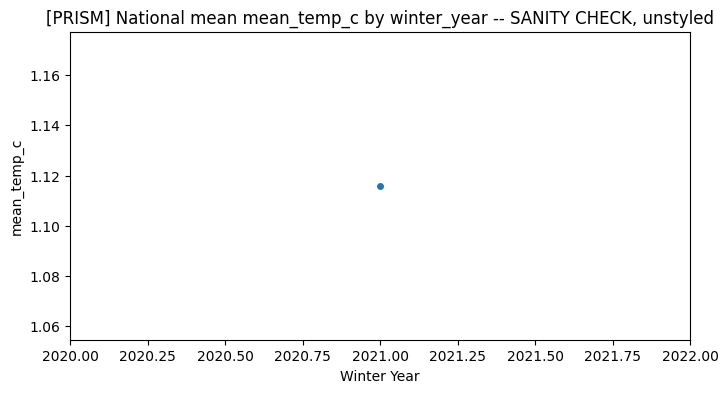

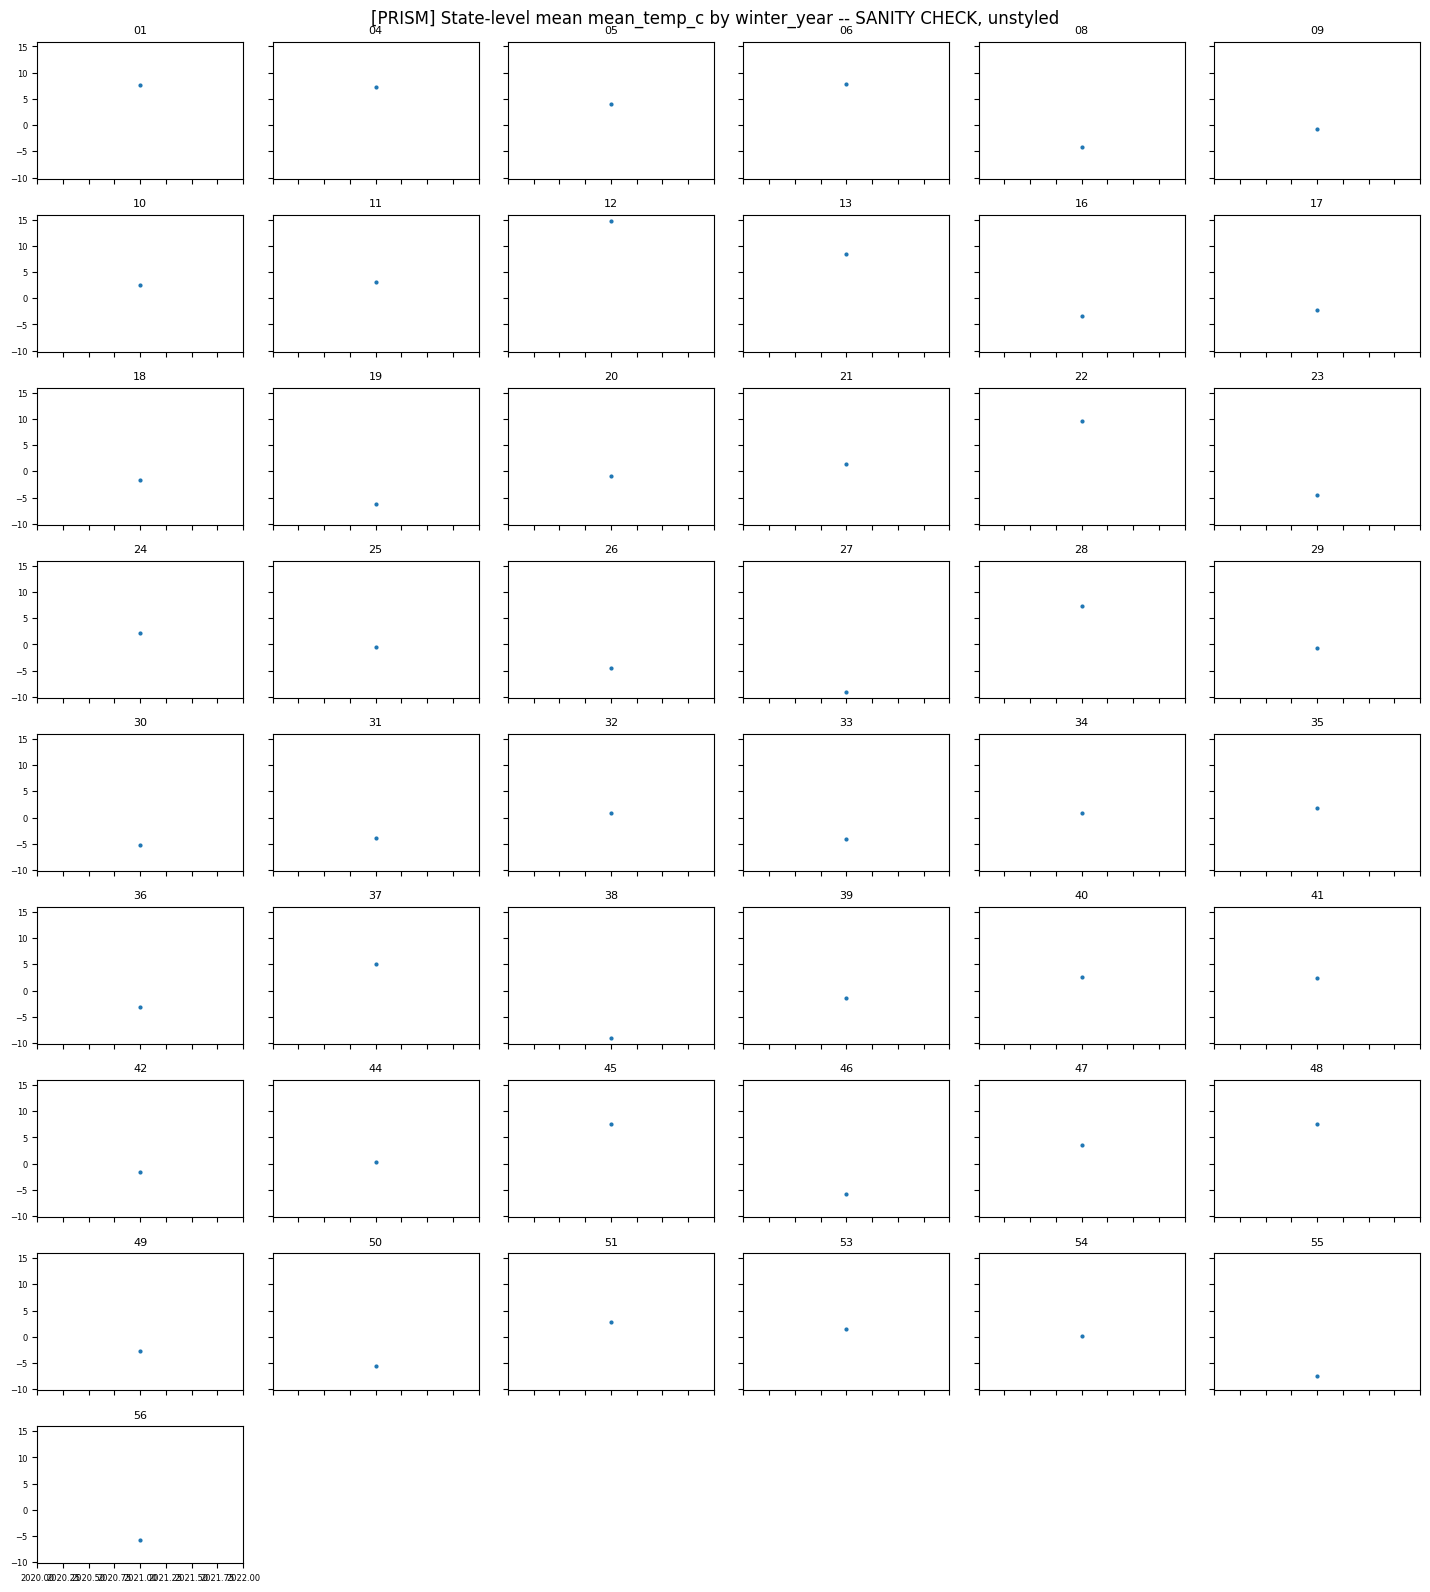

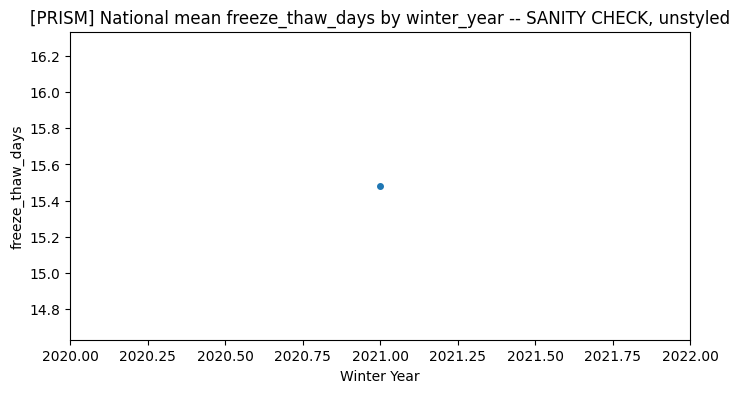

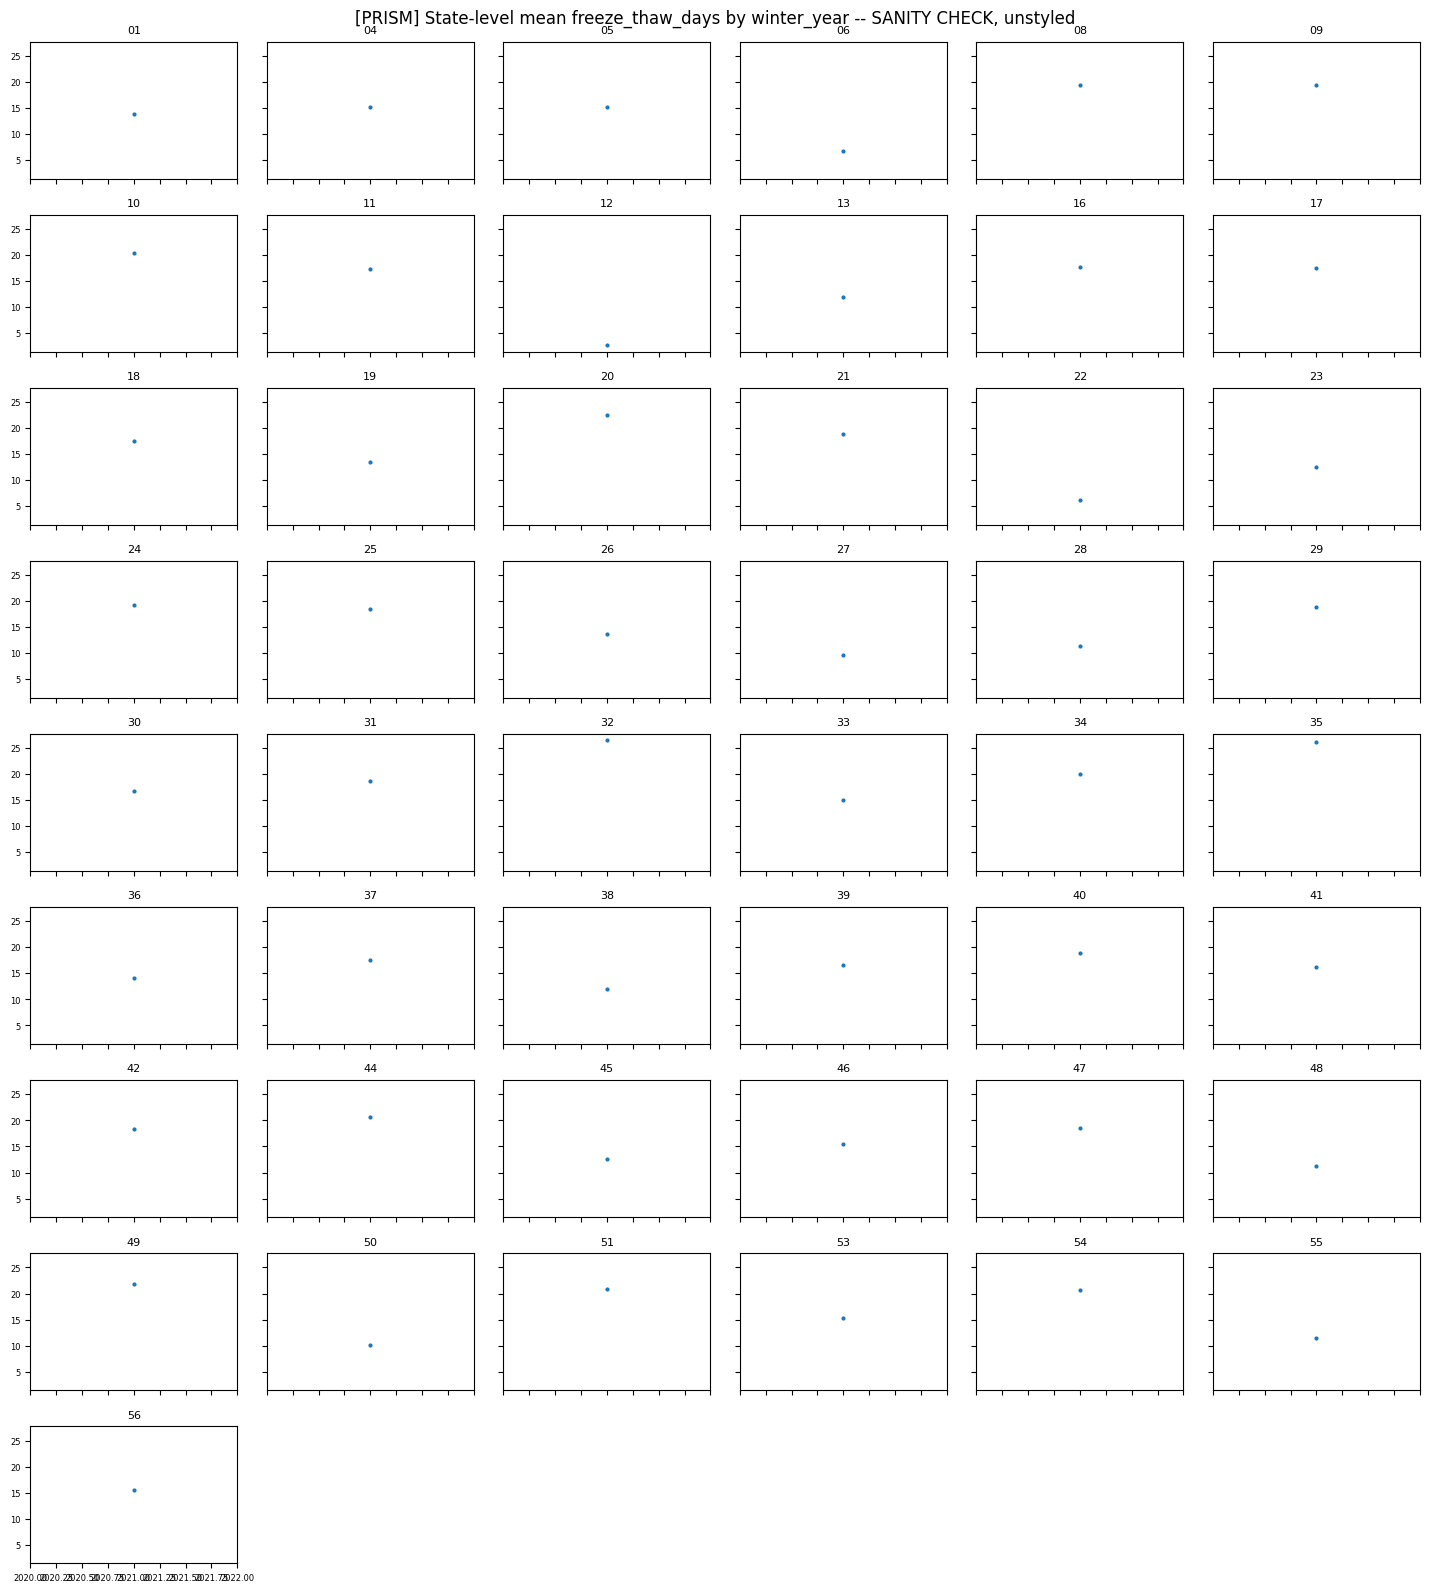

In [10]:
trend_vars = ["mean_temp_c", "days_below_freezing_32f", "freeze_thaw_days"]

for var in trend_vars:
    if var not in winter.columns:
        print(f"Skipping trend plots for {var!r}: not present in {config.name} panel.")
        continue
    plot_national_trend(winter, var, dataset_name=config.name)
    plot_state_small_multiples(winter, var, dataset_name=config.name)

## Per-county spaghetti plot (proof of concept)

One state, one trend line per county -- Eyal's specific ask on 8/18 to eyeball within-state variation, not just a single state-aggregate line. Scoped to one state here; scaling to all 50 may need a rethink (quartile bands instead of every county) once this is run against the full panel.

  Saved /tmp/repo_test/figures/weather/prism_sanity_county_spaghetti_mean_temp_c_state17.png


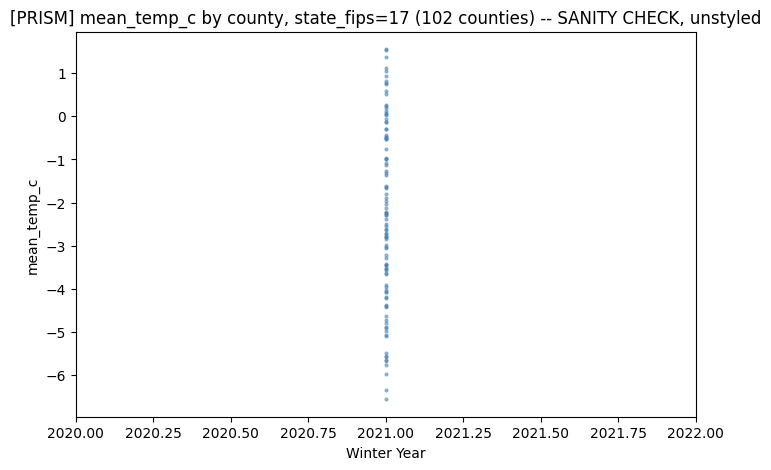

In [11]:
available_states = winter["state_fips"].unique()
poc_state = (
    PROOF_OF_CONCEPT_STATE_FIPS if PROOF_OF_CONCEPT_STATE_FIPS in available_states
    else sorted(available_states)[0]
)

if "mean_temp_c" in winter.columns:
    plot_county_spaghetti(winter, "mean_temp_c", state_fips=poc_state, dataset_name=config.name)

---

**Next steps:** switch `config` to `ERA5_CONFIG` above and re-run to see the same Tier 1 exhibits for ERA5 (secondary/robustness dataset). Tier 2 (decade distributions, anomaly frequency, choropleths) is still blocked in `09_descriptive_weather.py` pending a definition sign-off from Eyal -- not reproduced here.